<a href="https://colab.research.google.com/github/deepakvsajjan/nlp/blob/main/hotelreviewanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
df=pd.read_csv("/content/hotel_reviews.csv")

In [38]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 6994 entries, 0 to 7000
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Index              6994 non-null   int64  
 1   Name               6994 non-null   object 
 2   Area               6994 non-null   object 
 3   Review_Date        6994 non-null   object 
 4   Rating_attribute   6994 non-null   object 
 5   Rating(Out of 10)  6994 non-null   float64
 6   Review_Text        6994 non-null   object 
 7   Clean_Review       6994 non-null   object 
 8   Sentiment          6994 non-null   object 
 9   Issue              6994 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 601.0+ KB
None


In [5]:
print(df.head())

   Index             Name                  Area Review_Date  \
0      0  Hotel The Pearl  Paharganj, New Delhi      Jul-23   
1      1  Hotel The Pearl  Paharganj, New Delhi      Aug-23   
2      2  Hotel The Pearl  Paharganj, New Delhi      Aug-23   
3      3  Hotel The Pearl  Paharganj, New Delhi      Aug-23   
4      4  Hotel The Pearl  Paharganj, New Delhi      Aug-23   

                            Rating_attribute  Rating(Out of 10)  \
0                 Best budget friendly hotel                9.0   
1                              Amazing place                9.0   
2               Overall good stay. Economic.                9.0   
3                                     Lovely                9.0   
4  Great hotel Great staff and great staying                9.0   

                                         Review_Text  
0  Hotel the pearl is perfect place to stay in De...  
1  Location of the hotel is perfect. The hotel is...  
2                             Location, Indian food. 

In [6]:
df.isnull().sum()

,0
Index,0
Name,0
Area,0
Review_Date,0
Rating_attribute,0
Rating(Out of 10),0
Review_Text,7


In [7]:
df.dropna(inplace=True)

In [8]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [9]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

In [11]:
print(df.columns)

Index(['Index', 'Name', 'Area', 'Review_Date', 'Rating_attribute',
       'Rating(Out of 10)', 'Review_Text'],
      dtype='object')


In [12]:
df["Clean_Review"] = df["Rating_attribute"].apply(clean_text)

In [19]:
pip install textblob

In [22]:
# Install TextBlob (run once)
!pip install textblob

# Import TextBlob
from textblob import TextBlob

# Function to get sentiment
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

# Apply to DataFrame
df["Sentiment"] = df["Clean_Review"].apply(get_sentiment)

In [23]:
issues = {

    "Room":["room","bed","ac","bathroom"],

    "Staff":["staff","manager","reception"],

    "Food":["food","breakfast","restaurant"],

    "Cleanliness":["clean","dirty","dust"],

    "Amenities":["wifi","pool","gym","parking"]

}

In [24]:
def identify_issue(review):

    found=[]

    review=review.lower()

    for category, words in issues.items():

        for word in words:

            if word in review:

                found.append(category)

                break

    return ", ".join(found)

In [26]:
df["Issue"] = df["Rating_attribute"].apply(identify_issue)
df["Issue"].value_counts()

,count
Issue,
,6117
Room,388
Staff,202
Cleanliness,56
"Room, Staff",56
"Room, Cleanliness",49
Food,46
"Staff, Cleanliness",20
"Room, Staff, Cleanliness",17


In [27]:
from collections import Counter

text = " ".join(df["Clean_Review"])

words = text.split()

Counter(words).most_common(20)

[('good', 1908),
 ('exceptional', 779),
 ('stay', 727),
 ('superb', 691),
 ('bad', 569),
 ('hotel', 455),
 ('pleasant', 354),
 ('staff', 294),
 ('nice', 268),
 ('great', 260),
 ('passable', 214),
 ('room', 213),
 ('location', 212),
 ('experience', 196),
 ('comfortable', 184),
 ('poor', 182),
 ('place', 172),
 ('money', 160),
 ('value', 152),
 ('excellent', 135)]

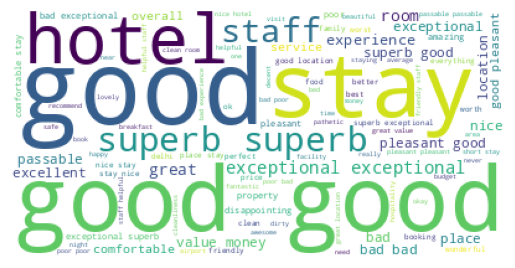

In [30]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
wc = WordCloud(background_color="white").generate(text)

plt.imshow(wc)

plt.axis("off")

plt.show()

In [31]:
positive = len(df[df["Sentiment"]=="Positive"])

total = len(df)

print("Positive Reviews:", positive)

print("Customer Satisfaction:",
      round((positive/total)*100,2),"%")

Positive Reviews: 5140
Customer Satisfaction: 73.49 %


In [39]:
print("Average Rating:", df["Rating(Out of 10)"].mean())
print(df["Issue"].value_counts())

Average Rating: 7.03372891049471
Issue
                            6117
Room                         388
Staff                        202
Cleanliness                   56
Room, Staff                   56
Room, Cleanliness             49
Food                          46
Staff, Cleanliness            20
Room, Staff, Cleanliness      17
Room, Food                    16
Staff, Food                   10
Room, Food, Cleanliness        5
Room, Staff, Food              5
Amenities                      3
Food, Cleanliness              2
Staff, Food, Cleanliness       1
Room, Amenities                1
Name: count, dtype: int64
